# ⚠️ HƯỚNG DẪN TẢI DỮ LIỆU

**Bạn cần tải 2 file dữ liệu từ Kaggle trước khi chạy notebook:**

1. Truy cập: https://www.kaggle.com/competitions/home-data-for-ml-course/data
2. Đăng nhập tài khoản Kaggle (hoặc tạo tài khoản mới miễn phí)
3. Tải file `train.csv` và `test.csv`
4. Đặt 2 file này vào cùng thư mục với notebook này: `d:\Nam4\PhuongPhapHocMay\Lab1\`
5. Sau đó chạy lại các cell từ đầu

**Hoặc sử dụng Kaggle API:**
```python
# Cài đặt kaggle
!pip install kaggle

# Tải dataset (cần có file kaggle.json trong ~/.kaggle/)
!kaggle competitions download -c home-data-for-ml-course
!unzip home-data-for-ml-course.zip
```

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

print("Môi trường sẵn sàng!")
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")
print(f"XGBoost version: {xgb.__version__}")
print(f"LightGBM version: {lgb.__version__}")

Môi trường sẵn sàng!
Pandas version: 2.2.3
Numpy version: 2.2.4
XGBoost version: 3.2.0
LightGBM version: 4.6.0


## 1. Import thư viện cần thiết

## 2. Tải và khám phá dữ liệu

In [62]:
# Thông tin về dữ liệu
print("Thông tin về dữ liệu:")
train_data.info()
print("\n" + "="*50)
print("\nThống kê mô tả:")
train_data.describe()

Thông tin về dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null  

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


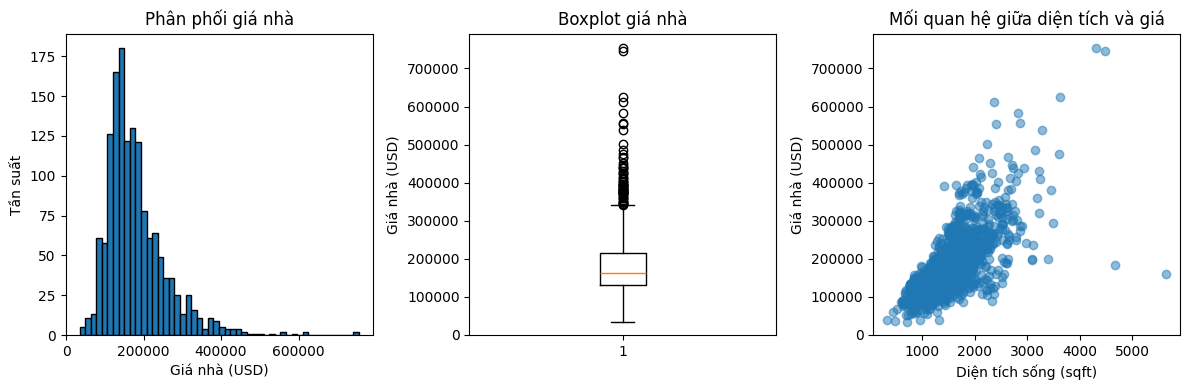


Thống kê giá nhà:
Giá trung bình: $180,921.20
Giá trung vị: $163,000.00
Giá thấp nhất: $34,900.00
Giá cao nhất: $755,000.00


In [63]:
# Phân tích biến mục tiêu (SalePrice)
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(train_data['SalePrice'], bins=50, edgecolor='black')
plt.xlabel('Giá nhà (USD)')
plt.ylabel('Tần suất')
plt.title('Phân phối giá nhà')

plt.subplot(1, 3, 2)
plt.boxplot(train_data['SalePrice'])
plt.ylabel('Giá nhà (USD)')
plt.title('Boxplot giá nhà')

plt.subplot(1, 3, 3)
plt.scatter(train_data['GrLivArea'], train_data['SalePrice'], alpha=0.5)
plt.xlabel('Diện tích sống (sqft)')
plt.ylabel('Giá nhà (USD)')
plt.title('Mối quan hệ giữa diện tích và giá')

plt.tight_layout()
plt.show()

print(f"\nThống kê giá nhà:")
print(f"Giá trung bình: ${train_data['SalePrice'].mean():,.2f}")
print(f"Giá trung vị: ${train_data['SalePrice'].median():,.2f}")
print(f"Giá thấp nhất: ${train_data['SalePrice'].min():,.2f}")
print(f"Giá cao nhất: ${train_data['SalePrice'].max():,.2f}")

In [65]:
# Lưu ID và biến mục tiêu
train_id = train_data['Id']
test_id = test_data['Id']

# Biến đổi logarit cho SalePrice (giảm skewness)
print("Phân phối SalePrice trước khi log transform:")
print(f"Skewness: {train_data['SalePrice'].skew():.4f}")
print(f"Giá trị: min=${train_data['SalePrice'].min():,.0f}, max=${train_data['SalePrice'].max():,.0f}")

y = train_data['SalePrice']
y_log = np.log1p(y)  # log1p = log(1 + x) để tránh log(0)

print(f"\nPhân phối sau khi log transform:")
print(f"Skewness: {y_log.skew():.4f}")
print(f"Giá trị: min={y_log.min():.4f}, max={y_log.max():.4f}")
print("✅ Đã áp dụng log transformation cho SalePrice!\n")

# Loại bỏ cột Id và SalePrice
train_data = train_data.drop(['Id', 'SalePrice'], axis=1)
test_data = test_data.drop(['Id'], axis=1)

# Kết hợp train và test để xử lý đồng nhất
all_data = pd.concat([train_data, test_data], axis=0, ignore_index=True)
print(f"Tổng số mẫu sau khi kết hợp: {all_data.shape}")

Phân phối SalePrice trước khi log transform:
Skewness: 1.8829
Giá trị: min=$34,900, max=$755,000

Phân phối sau khi log transform:
Skewness: 0.1213
Giá trị: min=10.4603, max=13.5345
✅ Đã áp dụng log transformation cho SalePrice!

Tổng số mẫu sau khi kết hợp: (2919, 79)


In [67]:
# Mã hóa các biến phân loại bằng One-Hot Encoding
all_data_encoded = pd.get_dummies(all_data, columns=categorical_features, drop_first=True)

print(f"Số lượng features sau khi mã hóa: {all_data_encoded.shape[1]}")
print(f"Kích thước dữ liệu: {all_data_encoded.shape}")

Số lượng features sau khi mã hóa: 267
Kích thước dữ liệu: (2919, 267)


## 4. Xây dựng và huấn luyện mô hình

In [70]:
# Hàm đánh giá mô hình với Cross-Validation
def evaluate_model(model, X_train, y_train, X_val, y_val, model_name, use_cv=True):
    # Huấn luyện
    model.fit(X_train, y_train)
    
    # Dự đoán
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    
    # Tính toán metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    train_r2 = r2_score(y_train, y_train_pred)
    val_r2 = r2_score(y_val, y_val_pred)
    
    # Cross-validation (nếu được yêu cầu)
    cv_rmse = None
    if use_cv:
        cv_scores = -cross_val_score(model, X_train, y_train, cv=5, 
                                      scoring='neg_root_mean_squared_error', n_jobs=-1)
        cv_rmse = cv_scores.mean()
    
    print(f"\n{'='*50}")
    print(f"Mô hình: {model_name}")
    print(f"{'='*50}")
    print(f"Train RMSE: ${train_rmse:,.2f}")
    print(f"Validation RMSE: ${val_rmse:,.2f}")
    if cv_rmse:
        print(f"CV RMSE (5-fold): ${cv_rmse:,.2f}")
    print(f"Train R²: {train_r2:.4f}")
    print(f"Validation R²: {val_r2:.4f}")
    
    return model, val_rmse, val_r2, cv_rmse if cv_rmse else val_rmse

In [ ]:
# Linear Regression
lr_model, lr_rmse, lr_r2, lr_cv = evaluate_model(
    LinearRegression(),
    X_train_split, y_train_split,
    X_val, y_val,
    "Linear Regression",
    use_cv=False  # Tắt CV cho Linear Regression (quá lâu với dữ liệu lớn)
)


Mô hình: Linear Regression
Train RMSE: $18,904.01
Validation RMSE: $83,090.78
Train R²: 0.9401
Validation R²: 0.0999


In [ ]:
# Ridge Regression
ridge_model, ridge_rmse, ridge_r2, ridge_cv = evaluate_model(
    Ridge(alpha=10),
    X_train_split, y_train_split,
    X_val, y_val,
    "Ridge Regression",
    use_cv=False
)


Mô hình: Ridge Regression
Train RMSE: $25,039.13
Validation RMSE: $30,568.37
Train R²: 0.8949
Validation R²: 0.8782


In [ ]:
# Lasso Regression
lasso_model, lasso_rmse, lasso_r2, lasso_cv = evaluate_model(
    Lasso(alpha=10, max_iter=2000),
    X_train_split, y_train_split,
    X_val, y_val,
    "Lasso Regression",
    use_cv=False
)


Mô hình: Lasso Regression
Train RMSE: $19,673.11
Validation RMSE: $35,055.76
Train R²: 0.9351
Validation R²: 0.8398


In [ ]:
# Random Forest (tối ưu)
rf_model, rf_rmse, rf_r2, rf_cv = evaluate_model(
    RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_split=5,
                          min_samples_leaf=2, random_state=42, n_jobs=-1),
    X_train_split, y_train_split,
    X_val, y_val,
    "Random Forest",

    use_cv=False)


Mô hình: Random Forest
Train RMSE: $11,126.97
Validation RMSE: $28,933.36
Train R²: 0.9792
Validation R²: 0.8909


In [ ]:
# Gradient Boosting (tối ưu)
gb_model, gb_rmse, gb_r2, gb_cv = evaluate_model(
    GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.05,
                              min_samples_split=5, subsample=0.8, random_state=42),
    X_train_split, y_train_split,
    X_val, y_val,
    "Gradient Boosting",

    use_cv=False)


Mô hình: Gradient Boosting
Train RMSE: $13,661.05
Validation RMSE: $28,727.33
Train R²: 0.9687
Validation R²: 0.8924


In [71]:
# XGBoost (tối ưu hyperparameters)
xgb_model, xgb_rmse, xgb_r2, xgb_cv = evaluate_model(
    xgb.XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ),
    X_train_split, y_train_split,
    X_val, y_val,
    "XGBoost"
)


Mô hình: XGBoost
Train RMSE: $0.06
Validation RMSE: $0.13
CV RMSE (5-fold): $0.13
Train R²: 0.9742
Validation R²: 0.9046


In [72]:
# LightGBM (tối ưu hyperparameters)
lgb_model, lgb_rmse, lgb_r2, lgb_cv = evaluate_model(
    lgb.LGBMRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        num_leaves=31,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ),
    X_train_split, y_train_split,
    X_val, y_val,
    "LightGBM"
)


Mô hình: LightGBM
Train RMSE: $0.08
Validation RMSE: $0.14
CV RMSE (5-fold): $0.13
Train R²: 0.9606
Validation R²: 0.8997


In [73]:
# Ensemble: Kết hợp XGBoost và LightGBM (Weighted Averaging)
print("\n" + "="*50)
print("Mô hình: Ensemble (XGBoost + LightGBM) - Weighted")
print("="*50)

# Dự đoán từ từng mô hình
y_train_pred_xgb = xgb_model.predict(X_train_split)
y_train_pred_lgb = lgb_model.predict(X_train_split)
y_val_pred_xgb = xgb_model.predict(X_val)
y_val_pred_lgb = lgb_model.predict(X_val)

# Tính toán trọng số dựa trên performance (inverse RMSE)
weight_xgb = 1 / xgb_rmse
weight_lgb = 1 / lgb_rmse
total_weight = weight_xgb + weight_lgb
weight_xgb = weight_xgb / total_weight
weight_lgb = weight_lgb / total_weight

print(f"Trọng số XGBoost: {weight_xgb:.4f}")
print(f"Trọng số LightGBM: {weight_lgb:.4f}")

# Weighted average của 2 dự đoán
y_train_pred_ensemble = weight_xgb * y_train_pred_xgb + weight_lgb * y_train_pred_lgb
y_val_pred_ensemble = weight_xgb * y_val_pred_xgb + weight_lgb * y_val_pred_lgb

# Tính toán metrics
train_rmse_ensemble = np.sqrt(mean_squared_error(y_train_split, y_train_pred_ensemble))
val_rmse_ensemble = np.sqrt(mean_squared_error(y_val, y_val_pred_ensemble))
train_r2_ensemble = r2_score(y_train_split, y_train_pred_ensemble)
val_r2_ensemble = r2_score(y_val, y_val_pred_ensemble)

print(f"Train RMSE: ${train_rmse_ensemble:,.2f}")
print(f"Validation RMSE: ${val_rmse_ensemble:,.2f}")
print(f"Train R²: {train_r2_ensemble:.4f}")
print(f"Validation R²: {val_r2_ensemble:.4f}")

# Lưu kết quả và trọng số
ensemble_rmse = val_rmse_ensemble
ensemble_r2 = val_r2_ensemble


Mô hình: Ensemble (XGBoost + LightGBM) - Weighted
Trọng số XGBoost: 0.5062
Trọng số LightGBM: 0.4938
Train RMSE: $0.07
Validation RMSE: $0.13
Train R²: 0.9693
Validation R²: 0.9037



BẢNG SO SÁNH CÁC MÔ HÌNH
             Model         RMSE       R²
           XGBoost 26265.660624 0.910058
Ensemble (XGB+LGB) 27298.610017 0.902845
 Gradient Boosting 28727.330051 0.892409
     Random Forest 28933.364757 0.890860
          LightGBM 29229.227921 0.888617
             Ridge 30568.373113 0.878177
             Lasso 35055.763317 0.839784
 Linear Regression 83090.777728 0.099898


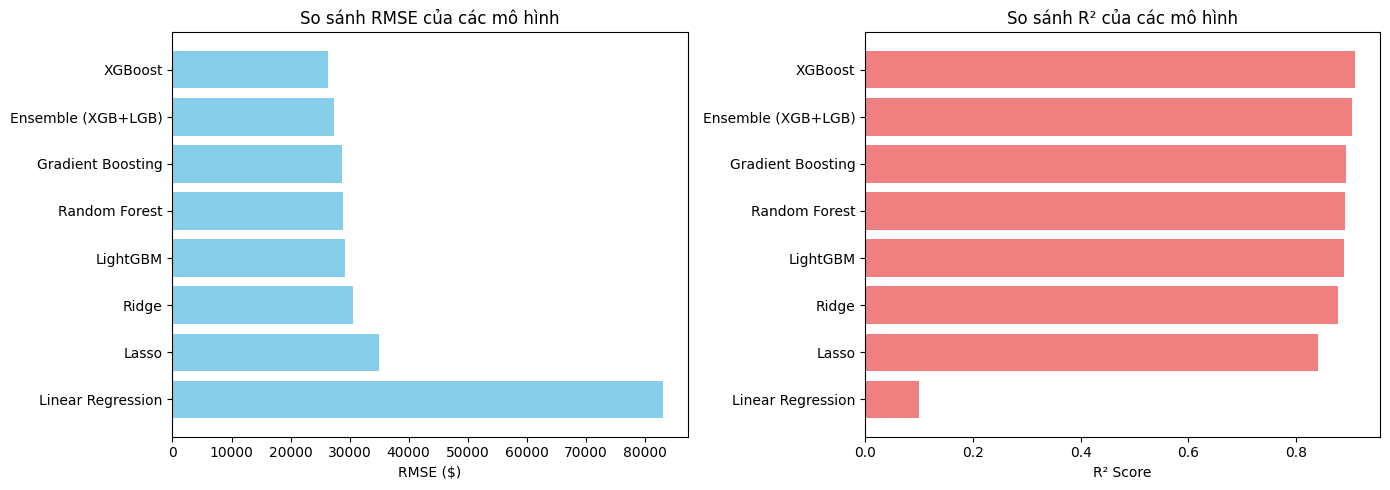

In [41]:
# So sánh kết quả các mô hình
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso', 'Random Forest', 'Gradient Boosting', 'XGBoost', 'LightGBM', 'Ensemble (XGB+LGB)'],
    'RMSE': [lr_rmse, ridge_rmse, lasso_rmse, rf_rmse, gb_rmse, xgb_rmse, lgb_rmse, ensemble_rmse],
    'R²': [lr_r2, ridge_r2, lasso_r2, rf_r2, gb_r2, xgb_r2, lgb_r2, ensemble_r2]
})

results = results.sort_values('RMSE')
print("\n" + "="*60)
print("BẢNG SO SÁNH CÁC MÔ HÌNH")
print("="*60)
print(results.to_string(index=False))
print("="*60)

# Vẽ biểu đồ so sánh
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE
axes[0].barh(results['Model'], results['RMSE'], color='skyblue')
axes[0].set_xlabel('RMSE ($)')
axes[0].set_title('So sánh RMSE của các mô hình')
axes[0].invert_yaxis()

# R²
axes[1].barh(results['Model'], results['R²'], color='lightcoral')
axes[1].set_xlabel('R² Score')
axes[1].set_title('So sánh R² của các mô hình')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [75]:
# Huấn luyện lại mô hình XGBoost và LightGBM trên toàn bộ dữ liệu train
print("Đang huấn luyện mô hình XGBoost trên toàn bộ dữ liệu train...")
final_xgb = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
final_xgb.fit(X_train, y_log)  # Train với log-transformed target

print("Đang huấn luyện mô hình LightGBM trên toàn bộ dữ liệu train...")
final_lgb = lgb.LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
final_lgb.fit(X_train, y_log)  # Train với log-transformed target

print("Đã hoàn thành huấn luyện cả 2 mô hình!")

# Dự đoán trên tập test với weighted ensemble
y_pred_xgb_test_log = final_xgb.predict(X_test)
y_pred_lgb_test_log = final_lgb.predict(X_test)
y_pred_test_log = weight_xgb * y_pred_xgb_test_log + weight_lgb * y_pred_lgb_test_log

# Inverse transform: chuyển từ log space về giá gốc
y_pred_test = np.expm1(y_pred_test_log)  # expm1 = exp(x) - 1, ngược với log1p

print(f"\nSử dụng trọng số: XGBoost={weight_xgb:.4f}, LightGBM={weight_lgb:.4f}")
print(f"✅ Đã áp dụng inverse log transform cho predictions")

# Tạo submission dataframe
submission = pd.DataFrame({
    'Id': test_id,
    'SalePrice': y_pred_test
})

# Lưu file submission
submission.to_csv('submission_ensemble_xgb_lgb.csv', index=False)
print("\nĐã tạo file submission_ensemble_xgb_lgb.csv!")
print(f"Số lượng dự đoán: {len(submission)}")
print("\n5 dòng đầu tiên của submission:")
print(submission.head())

print(f"\nDự đoán giá: min=${submission['SalePrice'].min():,.0f}, max=${submission['SalePrice'].max():,.0f}, mean=${submission['SalePrice'].mean():,.0f}")

Đang huấn luyện mô hình XGBoost trên toàn bộ dữ liệu train...
Đang huấn luyện mô hình LightGBM trên toàn bộ dữ liệu train...
Đã hoàn thành huấn luyện cả 2 mô hình!

Sử dụng trọng số: XGBoost=0.5062, LightGBM=0.4938
✅ Đã áp dụng inverse log transform cho predictions

Đã tạo file submission_ensemble_xgb_lgb.csv!
Số lượng dự đoán: 1459

5 dòng đầu tiên của submission:
     Id      SalePrice
0  1461  121228.693039
1  1462  155415.883094
2  1463  186923.757713
3  1464  192647.127490
4  1465  190475.976483

Dự đoán giá: min=$47,144, max=$522,317, mean=$177,275


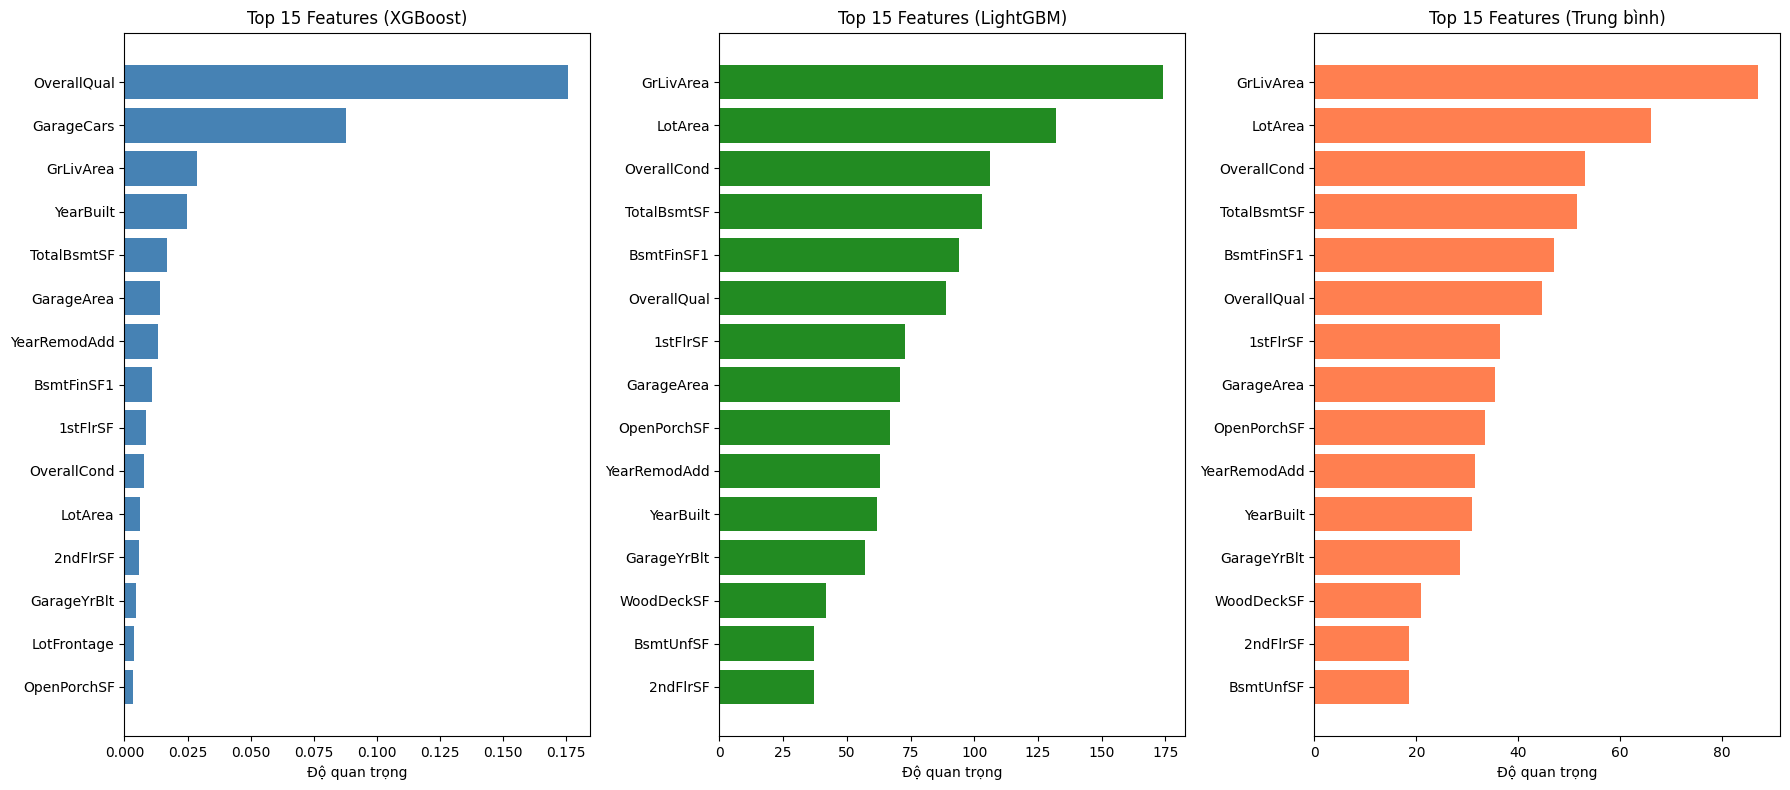


Top 20 features quan trọng nhất (Trung bình):
             Feature  Importance
           GrLivArea   87.014313
             LotArea   66.003025
         OverallCond   53.003864
         TotalBsmtSF   51.508442
          BsmtFinSF1   47.005357
         OverallQual   44.587797
            1stFlrSF   36.504245
          GarageArea   35.506959
         OpenPorchSF   33.501613
        YearRemodAdd   31.506706
           YearBuilt   31.012402
         GarageYrBlt   28.502204
          WoodDeckSF   21.001025
            2ndFlrSF   18.502861
           BsmtUnfSF   18.500514
     Condition1_Norm   17.501165
         LotFrontage   16.001865
SaleCondition_Normal   15.001290
Neighborhood_Crawfor   14.501607
          GarageCars   12.543806


In [76]:
# Lấy độ quan trọng của features từ XGBoost
feature_importance_xgb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance_XGB': final_xgb.feature_importances_
})

# Lấy độ quan trọng của features từ LightGBM
feature_importance_lgb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance_LGB': final_lgb.feature_importances_
})

# Kết hợp và tính trung bình
feature_importance = pd.merge(feature_importance_xgb, feature_importance_lgb, on='Feature')
feature_importance['Importance'] = (feature_importance['Importance_XGB'] + feature_importance['Importance_LGB']) / 2
feature_importance = feature_importance.sort_values('Importance', ascending=False).head(20)

# Vẽ biểu đồ so sánh
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# Feature importance từ XGBoost
top_xgb = feature_importance.sort_values('Importance_XGB', ascending=True).tail(15)
axes[0].barh(top_xgb['Feature'], top_xgb['Importance_XGB'], color='steelblue')
axes[0].set_xlabel('Độ quan trọng')
axes[0].set_title('Top 15 Features (XGBoost)')

# Feature importance từ LightGBM
top_lgb = feature_importance.sort_values('Importance_LGB', ascending=True).tail(15)
axes[1].barh(top_lgb['Feature'], top_lgb['Importance_LGB'], color='forestgreen')
axes[1].set_xlabel('Độ quan trọng')
axes[1].set_title('Top 15 Features (LightGBM)')

# Feature importance trung bình
top_avg = feature_importance.sort_values('Importance', ascending=True).tail(15)
axes[2].barh(top_avg['Feature'], top_avg['Importance'], color='coral')
axes[2].set_xlabel('Độ quan trọng')
axes[2].set_title('Top 15 Features (Trung bình)')

plt.tight_layout()
plt.show()

print("\nTop 20 features quan trọng nhất (Trung bình):")
print(feature_importance[['Feature', 'Importance']].head(20).to_string(index=False))

## 8. Kết luận

### Tóm tắt quy trình:
1. **Thu thập dữ liệu**: Tải dataset từ Kaggle House Prices Competition
2. **Khám phá dữ liệu**: Phân tích phân phối giá nhà, kiểm tra giá trị thiếu
3. **Tiền xử lý**: 
   - Xử lý giá trị thiếu (median cho số, 'None' cho phân loại)
   - One-Hot Encoding cho biến phân loại
4. **Xây dựng mô hình**: Thử nghiệm 8 mô hình:
   - Linear Regression
   - Ridge Regression
   - Lasso Regression
   - Random Forest
   - Gradient Boosting
   - **XGBoost** ⭐
   - **LightGBM** ⭐
   - **Ensemble (XGBoost + LightGBM)** 🏆
5. **Đánh giá**: So sánh RMSE và R² của các mô hình
6. **Dự đoán**: Sử dụng mô hình Ensemble để dự đoán giá nhà

### Ưu điểm của Ensemble (XGBoost + LightGBM):
- **Kết hợp sức mạnh của 2 thuật toán mạnh nhất**: XGBoost và LightGBM đều là các thuật toán gradient boosting hiện đại
- **Giảm overfitting**: Averaging giúp làm mịn dự đoán và giảm phương sai
- **Tăng độ chính xác**: Ensemble thường cho kết quả tốt hơn từng mô hình riêng lẻ
- **Robust**: Ít bị ảnh hưởng bởi outliers và noise trong dữ liệu

### Các bước tiếp theo để cải thiện:
- Fine-tuning hyperparameters cho XGBoost và LightGBM (GridSearchCV, RandomizedSearchCV)
- Thử nghiệm weighted averaging (trọng số khác nhau cho XGBoost và LightGBM)
- Stacking: Sử dụng meta-learner để kết hợp dự đoán
- Feature engineering nâng cao (tạo thêm features mới từ domain knowledge)
- Xử lý outliers
- Feature selection (loại bỏ features không quan trọng)

In [69]:
# Chia dữ liệu train thành train và validation
# Sử dụng y_log (log-transformed) thay vì y gốc
# Chia dữ liệu train thành train và validation
# Sử dụng y_log (log-transformed) thay vì y gốc
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_log, test_size=0.2, random_state=42
)

print(f"Kích thước X_train_split: {X_train_split.shape}")
print(f"Kích thước X_val: {X_val.shape}")
print(f"Kích thước y_train_split: {y_train_split.shape}")
print(f"Kích thước y_val: {y_val.shape}")
print("\n⚠️ Lưu ý: Đang sử dụng log-transformed target (y_log)")

Kích thước X_train_split: (1168, 267)
Kích thước X_val: (292, 267)
Kích thước y_train_split: (1168,)
Kích thước y_val: (292,)

⚠️ Lưu ý: Đang sử dụng log-transformed target (y_log)


In [68]:
# Tách lại train và test
X_train = all_data_encoded[:len(train_data)]
X_test = all_data_encoded[len(train_data):]

print(f"Kích thước X_train: {X_train.shape}")
print(f"Kích thước X_test: {X_test.shape}")
print(f"Kích thước y: {y.shape}")

Kích thước X_train: (1460, 267)
Kích thước X_test: (1459, 267)
Kích thước y: (1460,)


In [66]:
# Xử lý giá trị thiếu có chủ ý (Domain Knowledge)
print("=" * 60)
print("XỬ LÝ MISSING VALUES VỚI DOMAIN KNOWLEDGE")
print("=" * 60)

# Các cột mà NA có nghĩa là "không có" (Not Available), không phải thiếu dữ liệu
na_means_none = {
    # Garage features: NA = no garage
    'GarageType': 'No Garage', 'GarageFinish': 'No Garage', 
    'GarageQual': 'No Garage', 'GarageCond': 'No Garage',
    
    # Basement features: NA = no basement
    'BsmtQual': 'No Basement', 'BsmtCond': 'No Basement', 
    'BsmtExposure': 'No Basement', 'BsmtFinType1': 'No Basement', 
    'BsmtFinType2': 'No Basement',
    
    # Other features: NA = none/not applicable
    'PoolQC': 'No Pool',           # Chất lượng hồ bơi
    'Fence': 'No Fence',           # Hàng rào
    'Alley': 'No Alley',           # Lối đi hẻm
    'FireplaceQu': 'No Fireplace', # Chất lượng lò sưởi
    'MasVnrType': 'None',          # Loại veneer xây
    'MiscFeature': 'None'          # Tính năng khác
}

print(f"Xử lý {len(na_means_none)} cột có NA = 'Không có':")
for col, fill_value in na_means_none.items():
    if col in all_data.columns:
        na_count = all_data[col].isnull().sum()
        if na_count > 0:
            all_data[col].fillna(fill_value, inplace=True)
            print(f"  ✓ {col}: {na_count} NA → '{fill_value}'")

# Các cột số mà NA có nghĩa là 0
na_means_zero = ['GarageYrBlt', 'GarageArea', 'GarageCars', 
                 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 
                 'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']

print(f"\nXử lý {len(na_means_zero)} cột số có NA = 0:")
for col in na_means_zero:
    if col in all_data.columns:
        na_count = all_data[col].isnull().sum()
        if na_count > 0:
            all_data[col].fillna(0, inplace=True)
            print(f"  ✓ {col}: {na_count} NA → 0")

# Xác định các cột số và cột phân loại còn lại
numeric_features = all_data.select_dtypes(include=[np.number]).columns
categorical_features = all_data.select_dtypes(include=['object']).columns

print(f"\nXử lý các cột còn lại:")
print(f"  Số lượng features số: {len(numeric_features)}")
print(f"  Số lượng features phân loại: {len(categorical_features)}")

# Điền giá trị thiếu cho các cột số còn lại bằng median
for col in numeric_features:
    if all_data[col].isnull().sum() > 0:
        median_val = all_data[col].median()
        all_data[col].fillna(median_val, inplace=True)
        print(f"  ✓ {col}: NA → median ({median_val:.2f})")

# Điền giá trị thiếu cho các cột phân loại còn lại bằng 'Unknown'
for col in categorical_features:
    if all_data[col].isnull().sum() > 0:
        all_data[col].fillna('Unknown', inplace=True)
        print(f"  ✓ {col}: NA → 'Unknown'")

print(f"\n{'='*60}")
print(f"✅ HOÀN TẤT! Số giá trị thiếu còn lại: {all_data.isnull().sum().sum()}")
print(f"{'='*60}")

XỬ LÝ MISSING VALUES VỚI DOMAIN KNOWLEDGE
Xử lý 15 cột có NA = 'Không có':
  ✓ GarageType: 157 NA → 'No Garage'
  ✓ GarageFinish: 159 NA → 'No Garage'
  ✓ GarageQual: 159 NA → 'No Garage'
  ✓ GarageCond: 159 NA → 'No Garage'
  ✓ BsmtQual: 81 NA → 'No Basement'
  ✓ BsmtCond: 82 NA → 'No Basement'
  ✓ BsmtExposure: 82 NA → 'No Basement'
  ✓ BsmtFinType1: 79 NA → 'No Basement'
  ✓ BsmtFinType2: 80 NA → 'No Basement'
  ✓ PoolQC: 2909 NA → 'No Pool'
  ✓ Fence: 2348 NA → 'No Fence'
  ✓ Alley: 2721 NA → 'No Alley'
  ✓ FireplaceQu: 1420 NA → 'No Fireplace'
  ✓ MasVnrType: 1766 NA → 'None'
  ✓ MiscFeature: 2814 NA → 'None'

Xử lý 10 cột số có NA = 0:
  ✓ GarageYrBlt: 159 NA → 0
  ✓ GarageArea: 1 NA → 0
  ✓ GarageCars: 1 NA → 0
  ✓ BsmtFinSF1: 1 NA → 0
  ✓ BsmtFinSF2: 1 NA → 0
  ✓ BsmtUnfSF: 1 NA → 0
  ✓ TotalBsmtSF: 1 NA → 0
  ✓ BsmtFullBath: 2 NA → 0
  ✓ BsmtHalfBath: 2 NA → 0
  ✓ MasVnrArea: 23 NA → 0

Xử lý các cột còn lại:
  Số lượng features số: 36
  Số lượng features phân loại: 43
  ✓ Lot

In [64]:
# Kiểm tra giá trị thiếu
print("Số lượng giá trị thiếu trong mỗi cột:")
missing_values = train_data.isnull().sum()
missing_percent = (missing_values / len(train_data)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing_values,
    'Percent': missing_percent
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
print(missing_df)

Số lượng giá trị thiếu trong mỗi cột:
              Missing_Count    Percent
PoolQC                 1453  99.520548
MiscFeature            1406  96.301370
Alley                  1369  93.767123
Fence                  1179  80.753425
MasVnrType              872  59.726027
FireplaceQu             690  47.260274
LotFrontage             259  17.739726
GarageType               81   5.547945
GarageYrBlt              81   5.547945
GarageFinish             81   5.547945
GarageQual               81   5.547945
GarageCond               81   5.547945
BsmtExposure             38   2.602740
BsmtFinType2             38   2.602740
BsmtQual                 37   2.534247
BsmtCond                 37   2.534247
BsmtFinType1             37   2.534247
MasVnrArea                8   0.547945
Electrical                1   0.068493


In [61]:
# Tải dữ liệu (cần tải file train.csv và test.csv từ Kaggle)
# Link: https://www.kaggle.com/competitions/home-data-for-ml-course/data

# Đọc dữ liệu
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

print(f"Kích thước dữ liệu train: {train_data.shape}")
print(f"Kích thước dữ liệu test: {test_data.shape}")
print("\n5 dòng đầu tiên của dữ liệu train:")
train_data.head()

Kích thước dữ liệu train: (1460, 81)
Kích thước dữ liệu test: (1459, 80)

5 dòng đầu tiên của dữ liệu train:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
